<a href="https://colab.research.google.com/github/alessarana90-hue/NewCode/blob/main/IraqIranWithPreprocessingBiGRU%2BResnet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
!pip install tensorflow

In [ ]:
# Install necessary libraries
!pip install tensorflow scikit-learn imbalanced-learn

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Dropout, LSTM, Bidirectional, Input, BatchNormalization, Flatten, Concatenate
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

In [ ]:
train = pd.read_csv('/content/drive/MyDrive/iraq_iran_earthquake_final_data.csv') # loading train Dataset

In [ ]:
train .head(5)

,tweet_id,image_id,text_info,text_info_conf,image_info,image_info_conf,text_human,text_human_conf,image_human,image_human_conf,image_damage,image_damage_conf,tweet_text,image_url,image_path
0,9.299890e+17,929989361453621249_0,informative,1.0000,informative,0.6513,injured_or_dead_people,1.0000,other_relevant_information,0.6513,NaN,NaN,RT @PressTV: UPDATE: Death toll from Iran’s qu...,http://pbs.twimg.com/media/DOfT-eRWkAAJ_kB.jpg,data_image/iraq_iran_earthquake/13_11_2017/929...
1,9.299890e+17,929989388863508480_0,not_informative,0.7535,not_informative,1.0000,not_humanitarian,0.7535,not_humanitarian,1.0000,NaN,NaN,RT @CAFOD: We pray for all those affected by t...,http://pbs.twimg.com/media/DOftf6AW0AAzjkE.jpg,data_image/iraq_iran_earthquake/13_11_2017/929...
2,9.299890e+17,929989414826024960_0,informative,1.0000,not_informative,1.0000,injured_or_dead_people,1.0000,not_humanitarian,1.0000,NaN,NaN,RT @ReutersWorld: JUST IN: Death toll reaches ...,http://pbs.twimg.com/media/DOf76fBUMAAqpv_.jpg,data_image/iraq_iran_earthquake/13_11_2017/929...
3,9.299890e+17,929989443913691136_0,informative,1.0000,informative,0.6031,other_relevant_information,1.0000,injured_or_dead_people,0.6031,NaN,NaN,RT @LaylaAlhussein: A magnitude 7.2 earthquake...,http://pbs.twimg.com/media/DOeoQ75XUAEpZwN.jpg,data_image/iraq_iran_earthquake/13_11_2017/929...
4,9.299890e+17,929989443913691136_1,informative,1.0000,informative,1.0000,other_relevant_information,1.0000,rescue_volunteering_or_donation_effort,1.0000,NaN,NaN,RT @LaylaAlhussein: A magnitude 7.2 earthquake...,http://pbs.twimg.com/media/DOeoQ75WAAIsov_.jpg,data_image/iraq_iran_earthquake/13_11_2017/929...


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 597 entries, 0 to 596
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   tweet_id           597 non-null    float64
 1   image_id           597 non-null    object 
 2   text_info          597 non-null    object 
 3   text_info_conf     597 non-null    float64
 4   image_info         597 non-null    object 
 5   image_info_conf    597 non-null    float64
 6   text_human         597 non-null    object 
 7   text_human_conf    597 non-null    float64
 8   image_human        597 non-null    object 
 9   image_human_conf   597 non-null    float64
 10  image_damage       173 non-null    object 
 11  image_damage_conf  173 non-null    float64
 12  tweet_text         597 non-null    object 
 13  image_url          597 non-null    object 
 14  image_path         597 non-null    object 
dtypes: float64(6), object(9)
memory usage: 70.1+ KB


In [ ]:
import re
import nltk
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

In [ ]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
def remove_links(text):
    return re.sub(r'http\S+', '', text)

def remove_mentions(text):
    return re.sub(r'@\w+', '', text)

def remove_hashtags(text):
    return re.sub(r'#\w+', '', text)

def convert_to_lowercase(text):
    return text.lower()

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

def remove_emojis(text):
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                               u"\U00002500-\U00002BEF"  # chinese char
                               u"\U00002702-\U000027B0"
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"
                               u"\U0001f926-\U0001f937"
                               u"\U00010000-\U0010ffff"
                               u"\u2640-\u2642"
                               u"\u2600-\u2B55"
                               u"\u200d"
                               u"\u23cf"
                               u"\u23e9"
                               u"\u231a"
                               u"\ufe0f"  # dingbats
                               u"\u3030"
                               "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

In [ ]:
def remove_english_stopwords(text):
    arabic_stopwords = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [word for word in words if word not in arabic_stopwords]
    return ' '.join(filtered_words)

In [ ]:
train['tweet_text'] = train['tweet_text'].apply(remove_links)
train['tweet_text'] = train['tweet_text'].apply(remove_punctuation)
train['tweet_text'] = train['tweet_text'].apply(remove_emojis)
train['tweet_text'] = train['tweet_text'].apply(remove_english_stopwords)
train['tweet_text'] = train['tweet_text'].apply(convert_to_lowercase)
train['tweet_text'] = train['tweet_text'].apply(remove_mentions)
train['tweet_text'] = train['tweet_text'].apply(remove_hashtags)

In [ ]:
# Drop unnecessary columns
train.drop(['image_id', 'image_info', 'image_info_conf', 'image_human', 'image_human_conf',
            'image_damage', 'image_damage_conf', 'image_url', 'tweet_id',
            'text_info_conf', 'text_human_conf', 'text_human'], axis=1, inplace=True)

In [ ]:
train.tweet_text

,tweet_text
0,rt presstv update death toll iran’s quake rise...
1,rt cafod we pray affected earthquake iraq iran
2,rt reutersworld just in death toll reaches 328...
3,rt laylaalhussein a magnitude 72 earthquake st...
4,rt laylaalhussein a magnitude 72 earthquake st...
...,...
592,damage proxy maps 5 cities near epicenter kerm...
593,iran daily us treasury blocks donations earthq...
594,kurdish childrens situation earthquake in iran...
595,irans earthquake exposes political rifts and i...


In [ ]:
train.head(5)

,text_info,tweet_text,image_path
0,informative,rt presstv update death toll iran’s quake rise...,data_image/iraq_iran_earthquake/13_11_2017/929...
1,not_informative,rt cafod we pray affected earthquake iraq iran,data_image/iraq_iran_earthquake/13_11_2017/929...
2,informative,rt reutersworld just in death toll reaches 328...,data_image/iraq_iran_earthquake/13_11_2017/929...
3,informative,rt laylaalhussein a magnitude 72 earthquake st...,data_image/iraq_iran_earthquake/13_11_2017/929...
4,informative,rt laylaalhussein a magnitude 72 earthquake st...,data_image/iraq_iran_earthquake/13_11_2017/929...


In [ ]:
train['text_info'].unique()

array(['informative', 'not_informative'], dtype=object)

In [ ]:
# Encode the sentiment labels
label_encoder = LabelEncoder()
train['text_info'] = label_encoder.fit_transform(train['text_info'])

In [ ]:
train['text_info'].unique()

array([0, 1])

In [ ]:
train.head(5)

,text_info,tweet_text,image_path
0,0,rt presstv update death toll iran’s quake rise...,data_image/iraq_iran_earthquake/13_11_2017/929...
1,1,rt cafod we pray affected earthquake iraq iran,data_image/iraq_iran_earthquake/13_11_2017/929...
2,0,rt reutersworld just in death toll reaches 328...,data_image/iraq_iran_earthquake/13_11_2017/929...
3,0,rt laylaalhussein a magnitude 72 earthquake st...,data_image/iraq_iran_earthquake/13_11_2017/929...
4,0,rt laylaalhussein a magnitude 72 earthquake st...,data_image/iraq_iran_earthquake/13_11_2017/929...


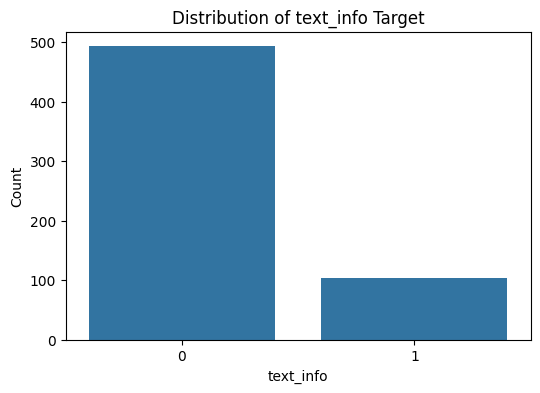

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of 'text_info' target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='text_info', data=train)
plt.title('Distribution of text_info Target')
plt.xlabel('text_info')
plt.ylabel('Count')
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# If train['tweet_text'] is a list of lists
if isinstance(train['tweet_text'][0], list):
    train['tweet_text'] = [' '.join(map(str, sublist)) for sublist in train['tweet_text']]

# Apply TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))  # Adjust the max_features as needed
X_text = vectorizer.fit_transform(train['tweet_text']).toarray()

In [ ]:
# Apply SMOTE to oversample the minority classes
smote = SMOTE(random_state=42)
X_text_resampled, y_resampled = smote.fit_resample(X_text, train['text_info'])

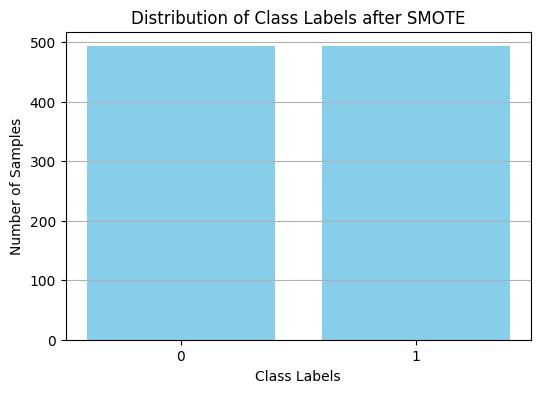

In [ ]:
# Count the occurrences of each class label
from collections import Counter

counter = Counter(y_resampled)

# Extract class labels and their corresponding counts
labels, values = zip(*counter.items())

# Plot the bar chart
plt.figure(figsize=(6, 4))
plt.bar(labels, values, color='skyblue')
plt.xlabel('Class Labels')
plt.ylabel('Number of Samples')
plt.title('Distribution of Class Labels after SMOTE')
plt.xticks(labels)
plt.grid(axis='y')
plt.show()

In [ ]:
len(train.text_info)

597

In [ ]:
# Normalize the features
scaler = StandardScaler(with_mean=False)
X_text_scaled = scaler.fit_transform(X_text_resampled)

In [ ]:
# Convert the target to categorical
y_categorical = to_categorical(y_resampled)

In [ ]:
# Step 1: Split data into 80% training+validation and 20% testing
X_text_train_val, X_text_test, y_train_val, y_test = train_test_split(X_text_scaled, y_categorical, test_size=0.2, random_state=42)

# Step 2: Split the 80% training+validation set into 70% training and 10% validation
X_text_train, X_text_val, y_train, y_val = train_test_split(X_text_train_val, y_train_val, test_size=0.125, random_state=42)

# Check the shapes to ensure the correct split
print(f"Training set size: {X_text_train.shape[0]} samples")
print(f"Validation set size: {X_text_val.shape[0]} samples")
print(f"Testing set size: {X_text_test.shape[0]} samples")

Training set size: 689 samples
Validation set size: 99 samples
Testing set size: 198 samples


In [ ]:
# Preprocess image data before dropping the 'image_path' column
import os
#train['image_path'] = '/content/drive/MyDrive/' + train['image_path']  # Prepend the path
image_paths = '/content/drive/MyDrive/' + train['image_path']  # Assuming image paths are now correctly formatted
image_data = []

for path in image_paths:
    if os.path.exists(path):
        img = load_img(path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = preprocess_input(img_array)
        image_data.append(img_array)
    else:
        print(f"File not found: {path}")

X_image = np.array(image_data)

In [ ]:
train.drop(['image_path'], axis=1, inplace=True)

In [ ]:
# Apply SMOTE to image data
X_image_resampled, _ = smote.fit_resample(X_image.reshape(len(X_image), -1), train['text_info'])
X_image_resampled = X_image_resampled.reshape(-1, 224, 224, 3)

In [ ]:
# Step 1: Split image data into 80% training+validation and 20% testing
X_image_train_val, X_image_test, y_train_val, y_test = train_test_split(X_image_resampled, y_resampled, test_size=0.2, random_state=42)

# Step 2: Split the 80% training+validation set into 70% training and 10% validation
X_image_train, X_image_val, y_train, y_val = train_test_split(X_image_train_val, y_train_val, test_size=0.125, random_state=42)

# Check the shapes to ensure the correct split
print(f"Training set size: {X_image_train.shape[0]} samples")
print(f"Validation set size: {X_image_val.shape[0]} samples")
print(f"Testing set size: {X_image_test.shape[0]} samples")

Training set size: 689 samples
Validation set size: 99 samples
Testing set size: 198 samples


In [ ]:
# Build ResNet model for image feature extraction
resnet_model = ResNet50(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
resnet_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
image_input = Input(shape=(224, 224, 3))
resnet_features = resnet_model(image_input)
resnet_features = Dropout(0.2)(resnet_features)
resnet_features = Flatten()(resnet_features)

In [ ]:
from keras.layers import Concatenate, Input
from keras.models import Model
from tensorflow.keras.layers import GRU

In [ ]:
# Reshape data for LSTM input (samples, timesteps, features)
X_text_train_reshaped = X_text_train.reshape((X_text_train.shape[0], 1, X_text_train.shape[1]))
X_text_val_reshaped = X_text_val.reshape((X_text_val.shape[0], 1, X_text_val.shape[1]))
X_text_test_reshaped = X_text_test.reshape((X_text_test.shape[0], 1, X_text_test.shape[1]))

In [ ]:
# Build BiGRU model for text feature extraction
text_input = Input(shape=(X_text_train_reshaped.shape[1], X_text_train_reshaped.shape[2]))
x = Bidirectional(GRU(128, return_sequences=True))(text_input)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Bidirectional(GRU(64, return_sequences=True))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Bidirectional(GRU(64))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

In [ ]:
# Concatenate image and text features
combined_features = Concatenate()([resnet_features, x])
combined_features = Dense(64, activation='relu')(combined_features)
combined_features = Dropout(0.2)(combined_features)
combined_features = Dense(32, activation='relu')(combined_features)
output = Dense(1, activation='sigmoid')(combined_features)

In [ ]:
# Build and compile the combined model
model = Model(inputs=[image_input, text_input], outputs=output)

In [ ]:
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 1, 4713)        │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional             │ (None, 1, 256)         │      3,719,424 │ input_layer_2[0][0]    │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 1, 256)         │          1,024 │ bidirectional[0][0]    │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 1, 256)         │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_1           │ (None, 1, 128)         │        123,648 │ dropout_1[0][0]        │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 1, 128)         │            512 │ bidirectional_1[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 1, 128)         │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ resnet50 (Functional)     │ (None, 7, 7, 2048)     │     23,587,712 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_2           │ (None, 128)            │         74,496 │ dropout_2[0][0]        │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 7, 7, 2048)     │              0 │ resnet50[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 128)            │            512 │ bidirectional_2[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 100352)         │              0 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 128)            │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 100480)         │              0 │ flatten[0][0],         │
│                           │                        │                │ dropout_3[0][0]        │
├──────────────────────

 Total params: 33,940,225 (129.47 MB)

 Trainable params: 10,351,489 (39.49 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

In [ ]:
# Train the combined model using the explicitly defined validation set
history = model.fit(
    [X_image_train, X_text_train_reshaped],  # Training data
    y_train,  # Training labels
    epochs=100,  # Number of epochs
    batch_size=32,  # Batch size
    validation_data=([X_image_val, X_text_val_reshaped], y_val),  # Validation data and labels
    verbose=1  # Verbosity mode
)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 390ms/step - accuracy: 0.6169 - loss: 3.0455 - val_accuracy: 0.8485 - val_loss: 0.3613
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 153ms/step - accuracy: 0.8597 - loss: 0.5398 - val_accuracy: 0.8687 - val_loss: 0.3346
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - accuracy: 0.9290 - loss: 0.2321 - val_accuracy: 0.9293 - val_loss: 0.1621
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step - accuracy: 0.9540 - loss: 0.1488 - val_accuracy: 0.9192 - val_loss: 0.1944
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step - accuracy: 0.9681 - loss: 0.1092 - val_accuracy: 0.9394 - val_loss: 0.2206
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.9788 - loss: 0.0358 - val_accuracy: 0.9394 - val_loss: 0.2912
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - accuracy: 0.9848 - loss: 0.0344 - val_accuracy: 0.9293 - val_loss: 0.4878
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.9869 - loss: 0.0379 - val_acc

In [ ]:
# Predict on the validation data
val_predictions = model.predict([X_image_val, X_text_val_reshaped])

# If y_val is already 1D, you don't need to use argmax
# Just proceed with the evaluation directly

val_predictions_binary = (val_predictions > 0.5).astype(int).flatten()

# Evaluate the model's performance on the validation data
val_accuracy = accuracy_score(y_val, val_predictions_binary)
val_precision = precision_score(y_val, val_predictions_binary)
val_recall = recall_score(y_val, val_predictions_binary)
val_f1 = f1_score(y_val, val_predictions_binary)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Precision: {val_precision:.4f}")
print(f"Validation Recall: {val_recall:.4f}")
print(f"Validation F1 Score: {val_f1:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 817ms/step
Validation Accuracy: 0.9495
Validation Precision: 0.9273
Validation Recall: 0.9808
Validation F1 Score: 0.9533


In [ ]:
# Make predictions on the test data
predictions = model.predict([X_image_test, X_text_test_reshaped])

# If y_val is already 1D, you don't need to use argmax
# Just proceed with the evaluation directly

test_predictions_binary = (predictions > 0.5).astype(int).flatten()

# Evaluate the model's performance on the test data
test_accuracy = accuracy_score(y_test, test_predictions_binary)
test_precision = precision_score(y_test, test_predictions_binary)
test_recall = recall_score(y_test, test_predictions_binary)
test_f1 = f1_score(y_test, test_predictions_binary)

print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Testing Precision: {test_precision:.4f}")
print(f"Testing Recall: {test_recall:.4f}")
print(f"Testing F1 Score: {test_f1:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step
Testing Accuracy: 0.9394
Testing Precision: 0.9062
Testing Recall: 0.9667
Testing F1 Score: 0.9355


Text(0.5, 0, 'Epochs')

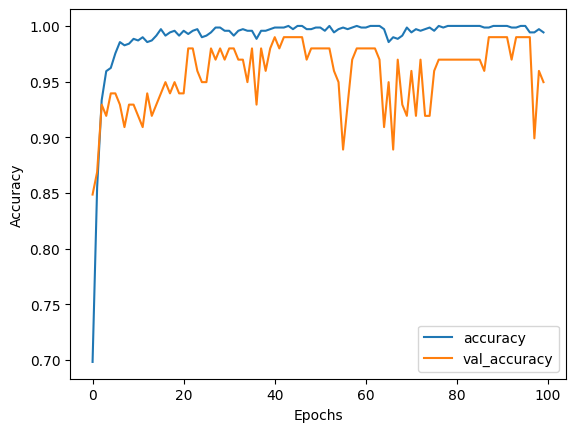

In [ ]:
pd.DataFrame(history.history)
pd.DataFrame(history.history)[['accuracy','val_accuracy']].plot()
plt.ylabel('Accuracy')
plt.xlabel('Epochs')

Text(0.5, 0, 'Epochs')

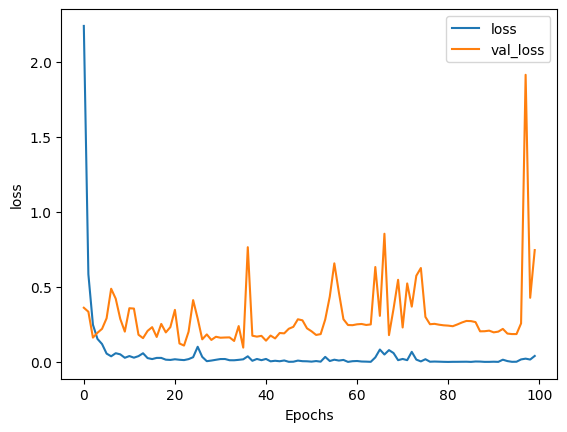

In [ ]:
pd.DataFrame(history.history)
pd.DataFrame(history.history)[['loss','val_loss']].plot()
plt.ylabel('loss')
plt.xlabel('Epochs')